## Chocolate Sales

![various chocolate bars](https://images.pexels.com/photos/4113305/pexels-photo-4113305.jpeg)
<sup>Author: Alleksana, pexels.com</sup>

---
format: 
    html:
        page-layout: full
        embed_resources: false
        grid: 
            body-width: 800px
            fontsize: 18pt
echo: True
warning: false
toc: True
---

In [1]:
# | echo: false
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold

## About the Dataset
The dataset used in this project contains transactional records of chocolate product sales across multiple countries and sales representatives.

Each row in the dataset represents a single sales transaction, including information about the product sold, the salesperson responsible, the country of sale, the transaction date, and the associated revenue and quantity.

:::{.content-hidden}



## Cleaning Dataset

In [2]:

or_df = pd.read_csv("Chocolate Sales (2).csv")
or_df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [3]:

or_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [4]:
# removing "$"
or_df["Amount"] = (
    or_df["Amount"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
or_df["Date"] = pd.to_datetime(or_df["Date"], dayfirst=True)
# creating date features
or_df["Year"] = or_df["Date"].dt.year
or_df["Month"] = or_df["Date"].dt.month
or_df["Month Label"] = or_df["Date"].dt.strftime("%Y-%m")
or_df["Quarter"] = "Q" + or_df["Date"].dt.quarter.astype(str)

or_df["Product"] = or_df["Product"].replace({
    'Smooth Sliky Salty': 'Smooth Silky Salty',
    'Drinking Coco': 'Drinking Choco'
})


In [5]:

or_df.to_csv("chocolate_sales_clean.csv", index=False)

:::

In [6]:
# | echo: false
df = pd.read_csv("chocolate_sales_clean.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Year,Month,Month Label,Quarter
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180,2022,1,2022-01,Q1
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94,2022,8,2022-08,Q3
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91,2022,7,2022-07,Q3
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342,2022,4,2022-04,Q2
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184,2022,2,2022-02,Q1


#### Information about Dataset

In [7]:
# | echo: false
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   object        
 1   Country        3282 non-null   object        
 2   Product        3282 non-null   object        
 3   Date           3282 non-null   datetime64[ns]
 4   Amount         3282 non-null   float64       
 5   Boxes Shipped  3282 non-null   int64         
 6   Year           3282 non-null   int64         
 7   Month          3282 non-null   int64         
 8   Month Label    3282 non-null   object        
 9   Quarter        3282 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 256.5+ KB


#### Overview for the Whole Dataset

In [8]:
# | echo: false
print(f"Sales Persons: {df['Sales Person'].unique()}\n")
print(f"Countries: {df['Country'].unique()}\n")
print(f"Products: {df['Product'].unique()}\n")
print(f"Range: {df['Date'].min()} - {df['Date'].max()}")
total_amount = df['Amount'].sum()
print(f"Total Amount: {total_amount.round(2)}")
total_boxes = df['Boxes Shipped'].sum()
print(f"Total Boxes Shipped: {total_boxes}")

Sales Persons: ['Jehu Rudeforth' 'Van Tuxwell' 'Gigi Bohling' 'Jan Morforth' 'Oby Sorrel'
 'Gunar Cockshoot' 'Brien Boise' 'Rafaelita Blaksland' 'Barr Faughny'
 'Mallorie Waber' 'Karlen McCaffrey' "Marney O'Breen" 'Beverie Moffet'
 'Roddy Speechley' 'Curtice Advani' 'Husein Augar' 'Kaine Padly'
 'Dennison Crosswaite' "Wilone O'Kielt" 'Andria Kimpton' 'Kelci Walkden'
 'Camilla Castle' 'Madelene Upcott' 'Dotty Strutley' 'Ches Bonnell']

Countries: ['UK' 'India' 'Australia' 'New Zealand' 'USA' 'Canada']

Products: ['Mint Chip Choco' '85% Dark Bars' 'Peanut Butter Cubes'
 'Smooth Silky Salty' '99% Dark & Pure' 'After Nines' '50% Dark Bites'
 'Orange Choco' 'Eclairs' 'Drinking Choco' 'Organic Choco Syrup'
 'Milk Bars' 'Spicy Special Slims' 'Fruit & Nut Bars' 'White Choc'
 'Manuka Honey Choco' 'Almond Choco' 'Raspberry Choco'
 'Choco Coated Almonds' "Baker's Choco Chips" 'Caramel Stuffed Bars'
 '70% Dark Bites']

Range: 2022-01-03 00:00:00 - 2024-08-31 00:00:00
Total Amount: 19791571.86
Tota

#### Overview for Years

In [9]:
# | echo: false
filtered_2022 = df[df["Year"] == 2022]
filtered_2023 = df[df["Year"] == 2023]
filtered_2024 = df[df["Year"] == 2024]

print("Earliest dates: ")
print(filtered_2022["Date"].min())
print(filtered_2023["Date"].min())
print(filtered_2024["Date"].min())
print("\nLatest dates: ")
print(filtered_2022["Date"].max())
print(filtered_2023["Date"].max())
print(filtered_2024["Date"].max())

print("\nSalesmen list for year 2022:")
print(filtered_2022["Sales Person"].unique())
print("\nSalesmen list for year 2023:")
print(filtered_2023["Sales Person"].unique())
print("\nSalesmen list for year 2024:")
print(filtered_2024["Sales Person"].unique())

print("\nProduct list for 2022: ")
print(filtered_2022["Product"].unique())
print("\nProduct list for 2023: ")
print(filtered_2023["Product"].unique())
print("\nProduct list for 2024: ")
print(filtered_2024["Product"].unique())

print("\nCountries list for year 2022: ")
print(filtered_2022["Country"].unique())
print("\nCountries list for year 2023: ")
print(filtered_2023["Country"].unique())
print("\nCountries list for year 2024: ")
print(filtered_2024["Country"].unique())

total_amount_2022= filtered_2022['Amount'].sum()
print(f"\nTotal Amount in 2022: {total_amount_2022.round(2)}")
total_boxes_2022 = filtered_2022['Boxes Shipped'].sum()
print(f"Total Boxes Shipped in 2022: {total_boxes_2022}")

total_amount_2023 = filtered_2023['Amount'].sum()
print(f"\nTotal Amount in 2023: {total_amount_2023.round(2)}")
total_boxes_2023 = filtered_2023['Boxes Shipped'].sum()
print(f"Total Boxes Shipped 2023: {total_boxes_2023}")

total_amount_2024 = filtered_2024['Amount'].sum()
print(f"\nTotal Amount in 2024: {total_amount_2024.round(2)}")
total_boxes_2024 = filtered_2024['Boxes Shipped'].sum()
print(f"Total Boxes Shipped in 2024: {total_boxes_2024}")

Earliest dates: 
2022-01-03 00:00:00
2023-01-03 00:00:00
2024-01-03 00:00:00

Latest dates: 
2022-08-31 00:00:00
2023-08-31 00:00:00
2024-08-31 00:00:00

Salesmen list for year 2022:
['Jehu Rudeforth' 'Van Tuxwell' 'Gigi Bohling' 'Jan Morforth' 'Oby Sorrel'
 'Gunar Cockshoot' 'Brien Boise' 'Rafaelita Blaksland' 'Barr Faughny'
 'Mallorie Waber' 'Karlen McCaffrey' "Marney O'Breen" 'Beverie Moffet'
 'Roddy Speechley' 'Curtice Advani' 'Husein Augar' 'Kaine Padly'
 'Dennison Crosswaite' "Wilone O'Kielt" 'Andria Kimpton' 'Kelci Walkden'
 'Camilla Castle' 'Madelene Upcott' 'Dotty Strutley' 'Ches Bonnell']

Salesmen list for year 2023:
['Jehu Rudeforth' 'Van Tuxwell' 'Gigi Bohling' 'Jan Morforth' 'Oby Sorrel'
 'Gunar Cockshoot' 'Brien Boise' 'Rafaelita Blaksland' 'Barr Faughny'
 'Mallorie Waber' 'Karlen McCaffrey' "Marney O'Breen" 'Beverie Moffet'
 'Roddy Speechley' 'Curtice Advani' 'Husein Augar' 'Kaine Padly'
 'Dennison Crosswaite' "Wilone O'Kielt" 'Andria Kimpton' 'Kelci Walkden'
 'Camilla 

## Exploratory Data Analysis

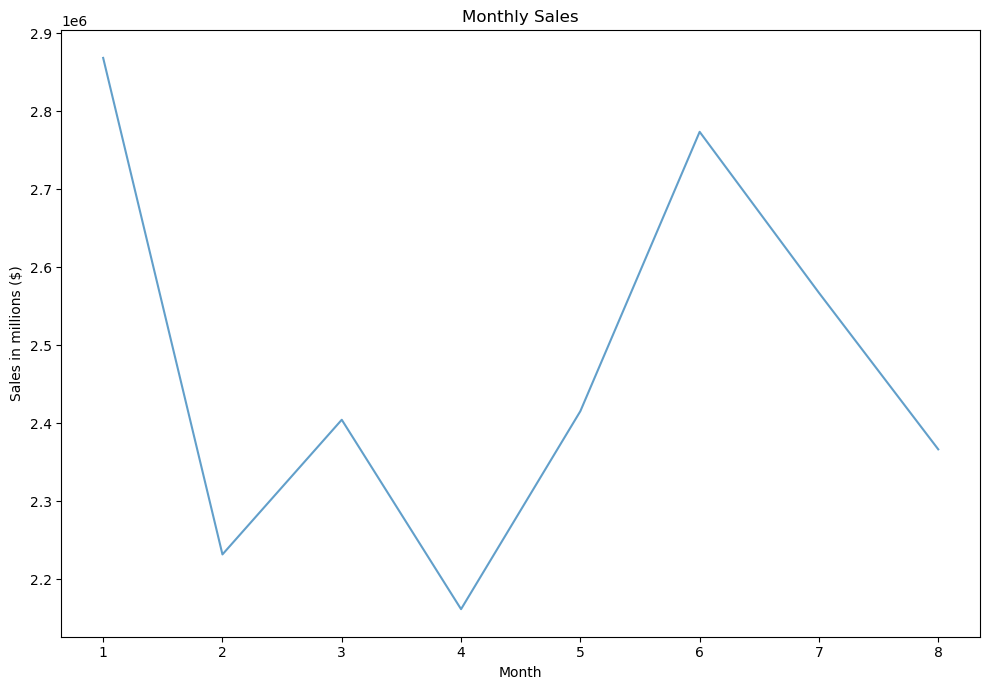

In [10]:
# | echo: false
monthly_sales = df.groupby("Month")["Amount"].sum().reset_index().sort_values("Month")
plt.figure(figsize=(10, 7))
plt.plot( monthly_sales["Month"], monthly_sales["Amount"], alpha=0.7)
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales in millions ($)")
plt.xticks()
plt.tight_layout()
plt.show()

Monthly sales show a seasonal pattern with a mid-period dip (April), strong recovery, and peak around June followed by a gradual decline. What is atypical is the period of sales from January to August only.

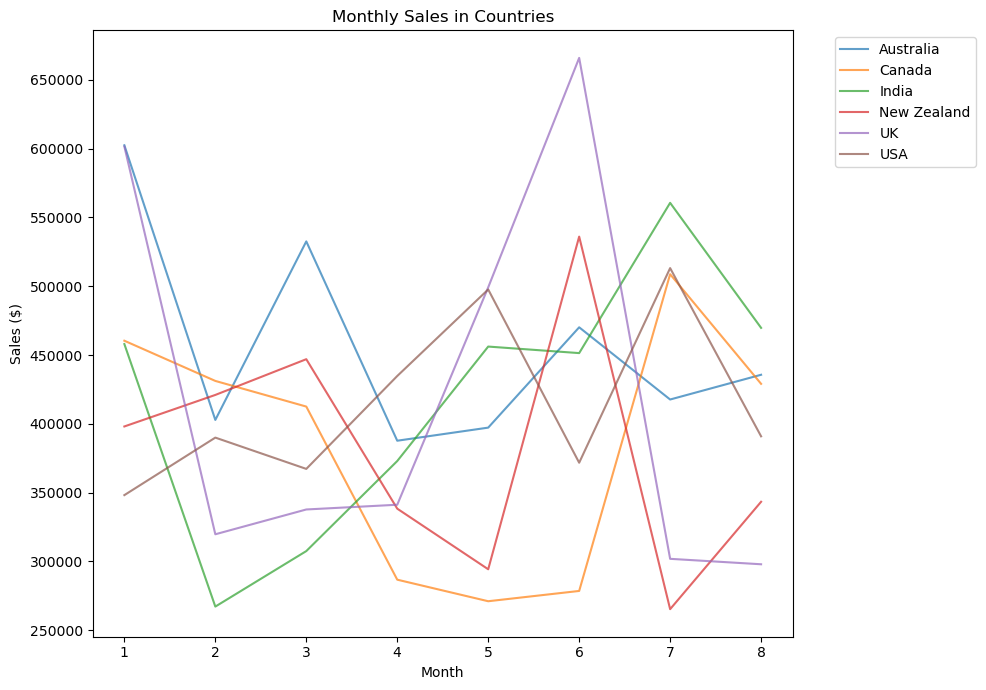

In [11]:
# | echo: false
monthly_sales_country = df.groupby(["Month", "Country"])["Amount"].sum().reset_index().sort_values(["Month", "Country"])
plt.figure(figsize=(10, 7))

for country in monthly_sales_country["Country"].unique():
    country_data = monthly_sales_country[monthly_sales_country["Country"] == country]

    plt.plot(
        country_data["Month"],
        country_data["Amount"],
        label=country,
        alpha=0.7
    )

plt.title("Monthly Sales in Countries")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks()

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Sales vary strongly by country, with a common mid-year peak (Month 6–7), high volatility in UK/New Zealand, and steady growth in India.

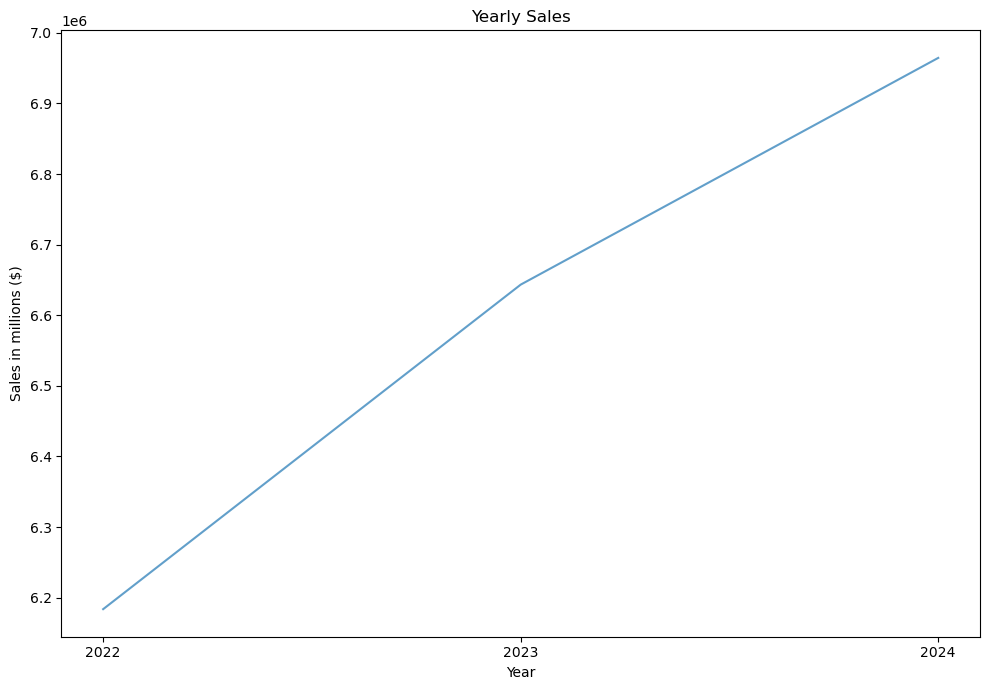

In [12]:
# | echo: false
yearly_sales = df.groupby("Year")["Amount"].sum().reset_index().sort_values("Year")
plt.figure(figsize=(10, 7))
plt.plot( yearly_sales["Year"], yearly_sales["Amount"], alpha=0.7)
plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales in millions ($)")
plt.xticks(yearly_sales["Year"].unique())
plt.tight_layout()
plt.show()

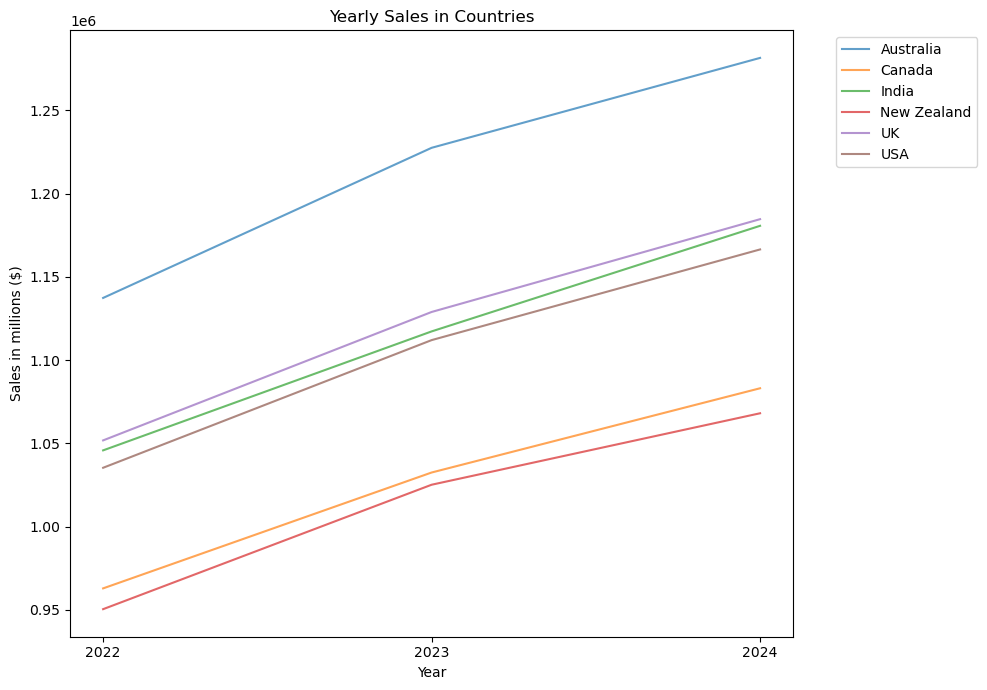

In [13]:
# | echo: false
yearly_sales_country = df.groupby(["Year", "Country"])["Amount"].sum().reset_index().sort_values(["Year", "Country"])
plt.figure(figsize=(10, 7))

for country in yearly_sales_country["Country"].unique():
    country_data = yearly_sales_country[yearly_sales_country["Country"] == country]

    plt.plot(
        country_data["Year"],
        country_data["Amount"],
        label=country,
        alpha=0.7
    )

plt.title("Yearly Sales in Countries")
plt.xlabel("Year")
plt.ylabel("Sales in millions ($)")
plt.xticks(yearly_sales_country["Year"].unique())

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

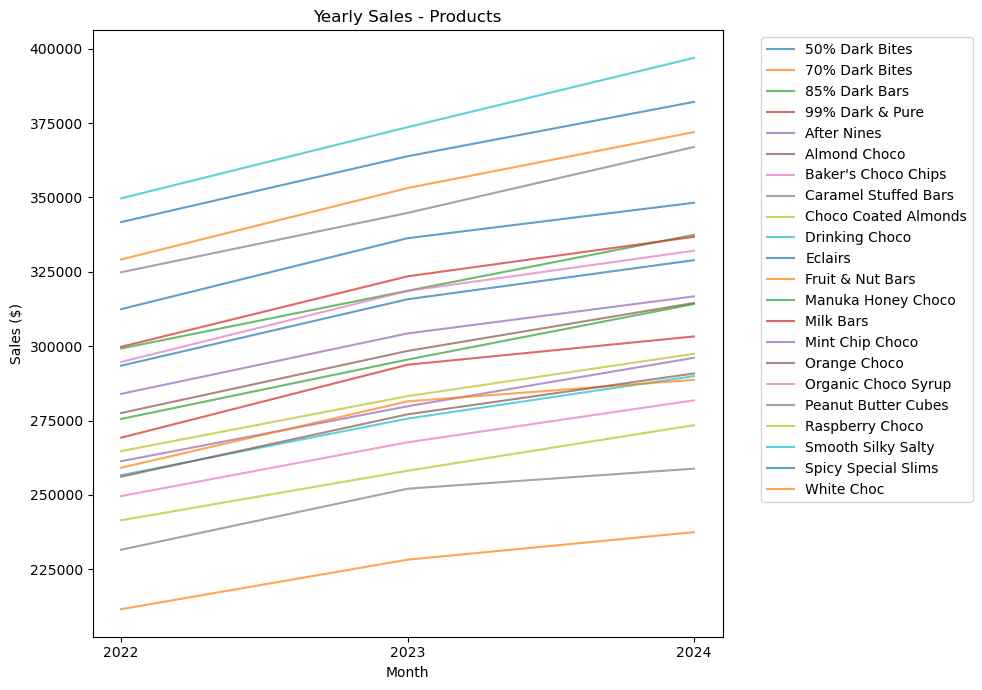

In [14]:
# | echo: false
yearly_sales_products = df.groupby(["Year", "Product"])["Amount"].sum().reset_index().sort_values(["Year", "Product"])
plt.figure(figsize=(10, 7))

for product in yearly_sales_products["Product"].unique():
    product_data_year = yearly_sales_products[yearly_sales_products["Product"] == product]

    plt.plot(
        product_data_year["Year"],
        product_data_year["Amount"],
        label=product,
        alpha=0.7
    )

plt.title("Yearly Sales - Products")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(yearly_sales_products["Year"].unique())

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

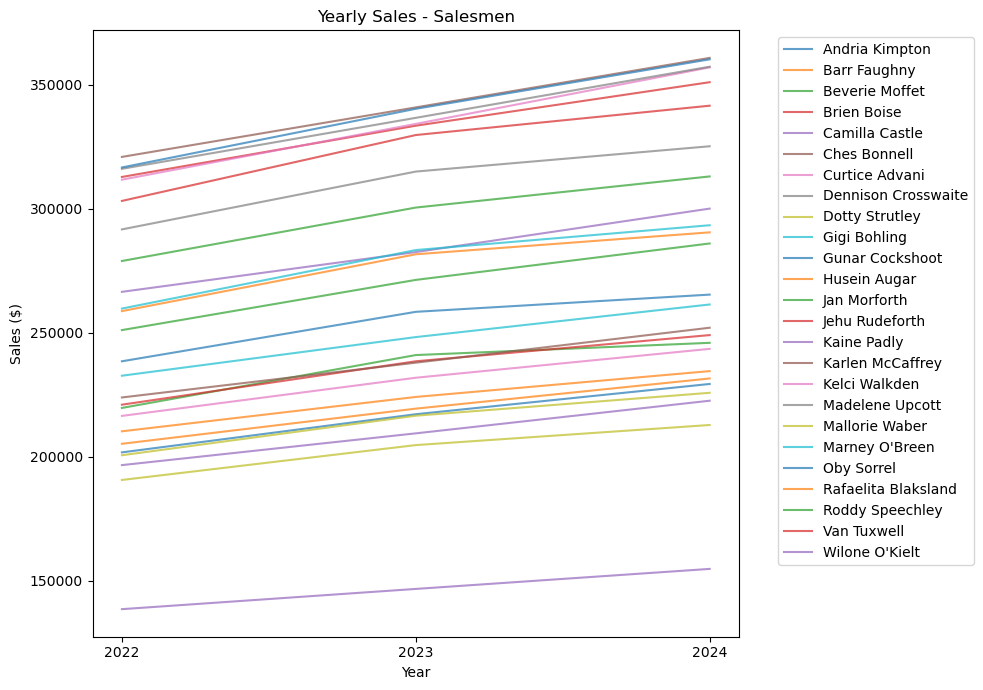

In [15]:
# | echo: false
yearly_sales_person = df.groupby(["Year", "Sales Person"])["Amount"].sum().reset_index().sort_values(["Year", "Sales Person"])
plt.figure(figsize=(10, 7))

for person in yearly_sales_person["Sales Person"].unique():
    person_data_year = yearly_sales_person[yearly_sales_person["Sales Person"] == person]

    plt.plot(
        person_data_year["Year"],
        person_data_year["Amount"],
        label=person,
        alpha=0.7,
    )

plt.title("Yearly Sales - Salesmen")
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.xticks(yearly_sales_person["Year"].unique())

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

The business shows strong, consistent, and diversified growth across years, countries, products, and salesmen. 

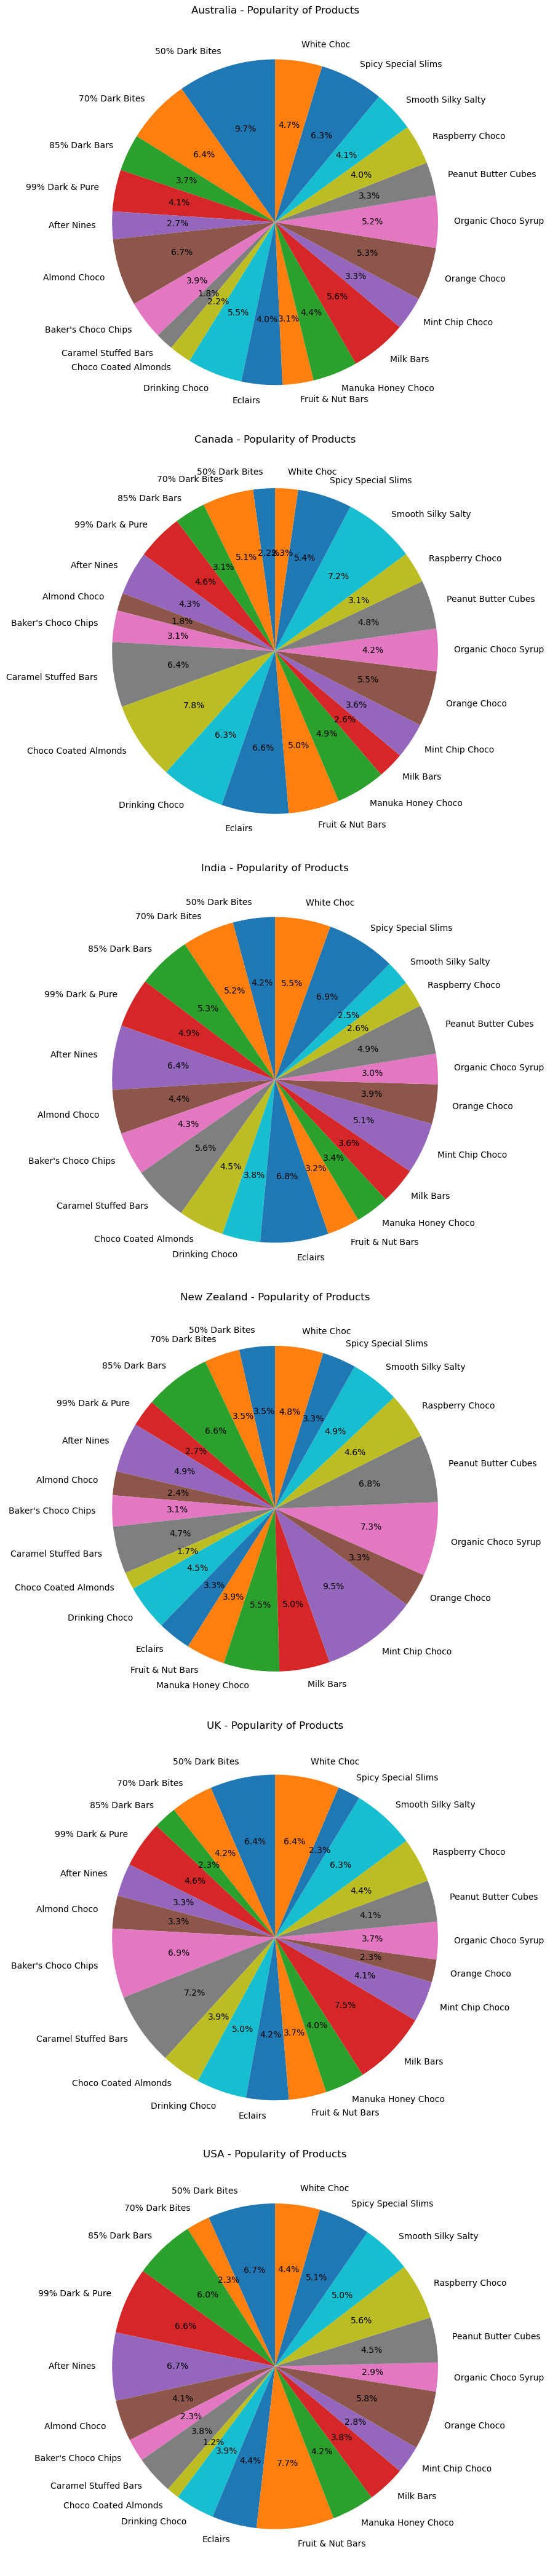

In [16]:
# | echo: false
pie_product = df.groupby(["Country", "Product"])["Boxes Shipped"].sum().reset_index()
countries = pie_product["Country"].unique()

fig, axes = plt.subplots(nrows=len(countries), figsize=(10, 7 * len(countries)))


if len(countries) == 1:
    axes = [axes]

for ax, country in zip(axes, countries):
    country_data = pie_product[pie_product["Country"] == country]

    ax.pie(
        country_data["Boxes Shipped"],
        labels=country_data["Product"],
        autopct="%1.1f%%",
        startangle=90
    )

    ax.set_title(f"{country} - Popularity of Products")

plt.tight_layout()
plt.show()

The charts represent product popularity based on sales volume, showing that demand is well distributed across products. Common winners across countries are Eclairs, Milk Bars, and Dark chocolate variants.

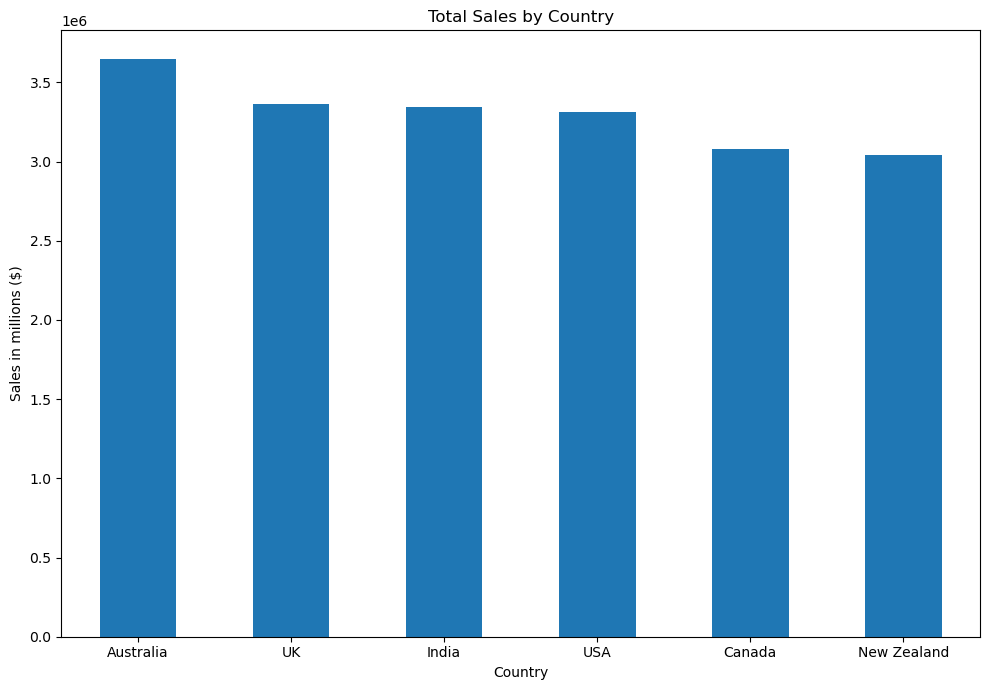

In [17]:
# | echo: false
sales_country = df.groupby("Country")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sales_country.plot(kind="bar")

plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales in millions ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sales are evenly distributed across countries, with Australia leading slightly, while all other markets contribute at similar levels—indicating a well-balanced and globally diversified business.

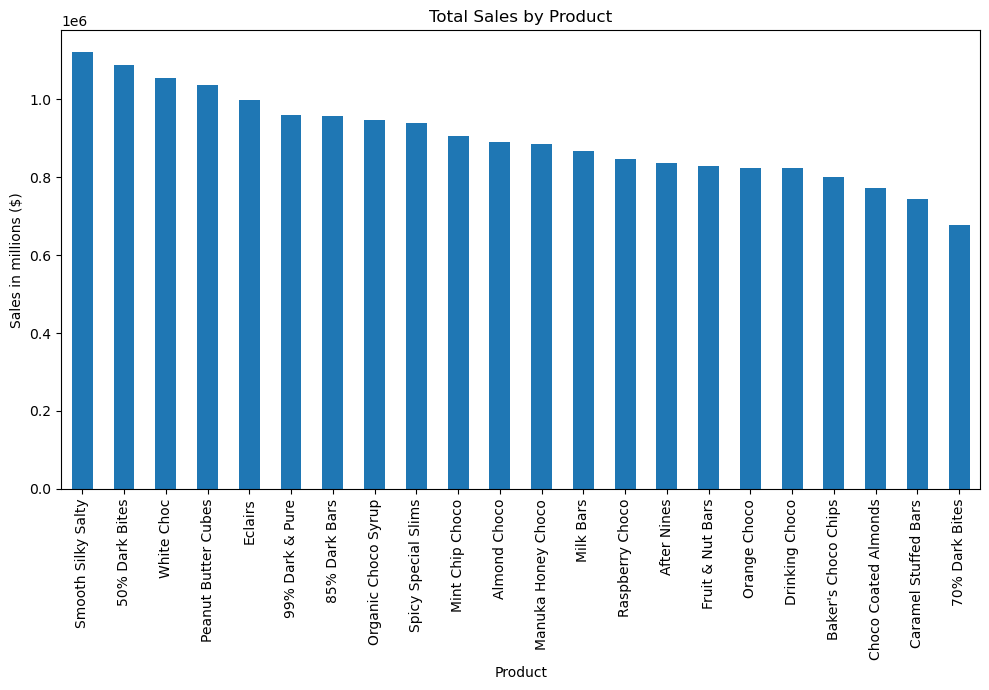

In [18]:
# | echo: false
sales_product = df.groupby("Product")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sales_product.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales in millions ($)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Top Performers are: Smooth Silky Salty (~1.12M), followed by 50% Dark Bites, White Choc, and Peanut Butter Cubes.

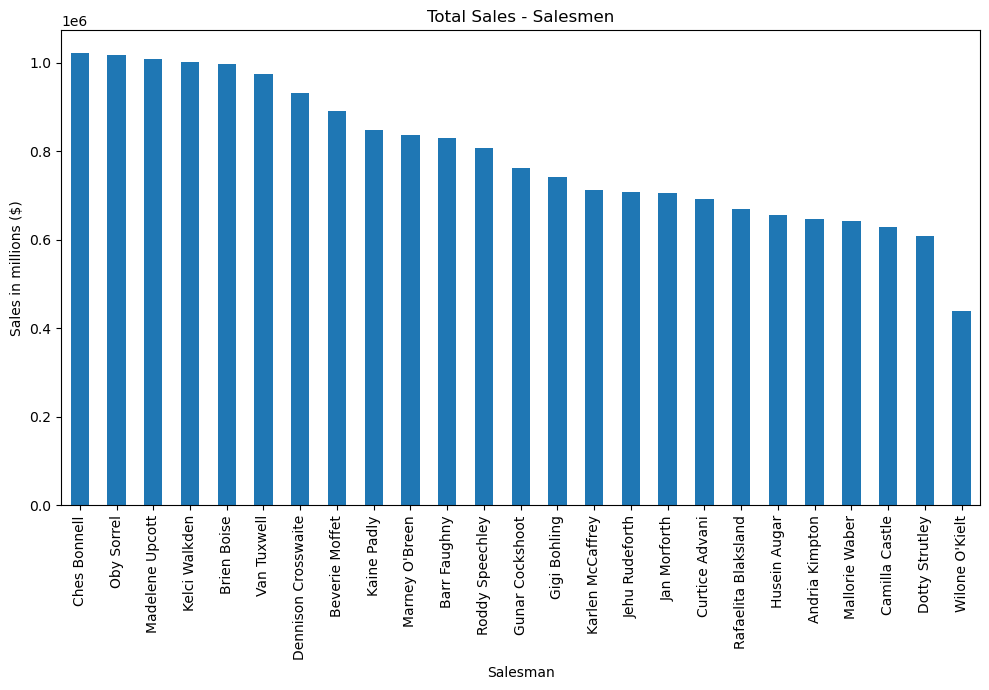

In [19]:
# | echo: false
sales_person = df.groupby("Sales Person")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sales_person.plot(kind="bar")

plt.title("Total Sales - Salesmen")
plt.xlabel("Salesman")
plt.ylabel("Sales in millions ($)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Leading salesmen are Ches Bonnell (~1.02M), Oby Sorrel, Madelene Upcott, Kelci Walkden, and Brien Boise.

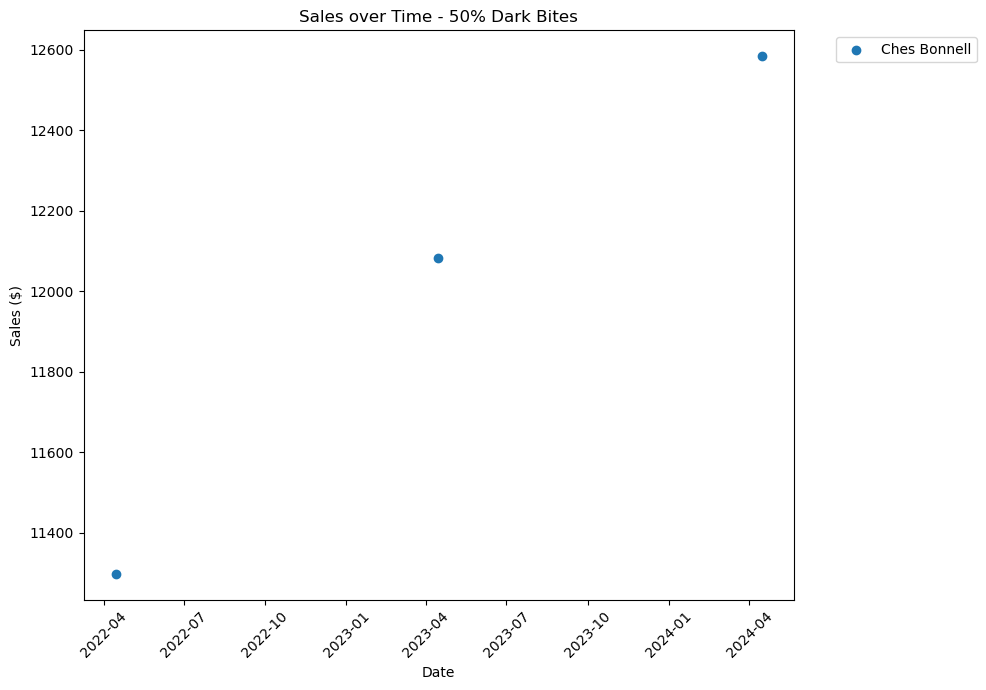

In [20]:
# | echo: false
salesman = "Ches Bonnell"
product = "50% Dark Bites"

# filter data
filtered = df[
    (df["Sales Person"] == salesman) &
    (df["Product"] == product)
]

# scatter plot
plt.figure(figsize=(10,7))
plt.scatter(filtered["Date"], filtered["Amount"], label="Ches Bonnell")

plt.title(f"Sales over Time - {product}")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

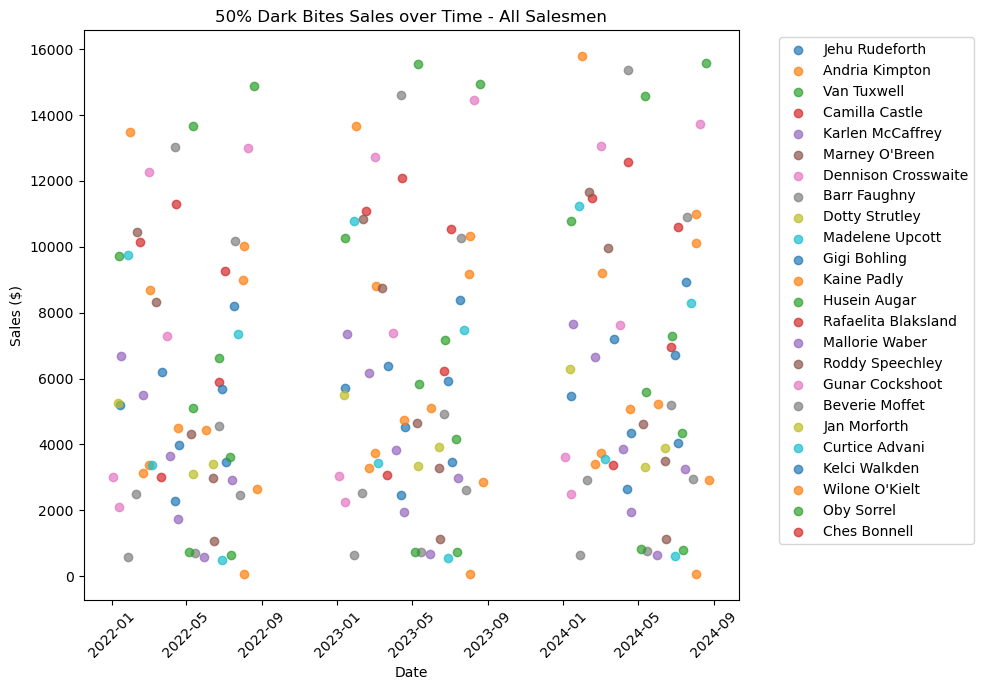

In [21]:
# | echo: false
product = "50% Dark Bites"

filtered = df[df["Product"] == product]

plt.figure(figsize=(10, 7))

for person in filtered["Sales Person"].unique():
    person_data = filtered[filtered["Sales Person"] == person]

    plt.scatter(
        person_data["Date"],
        person_data["Amount"],
        label=person,
        alpha=0.7
    )

plt.title(f"{product} Sales over Time - All Salesmen")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

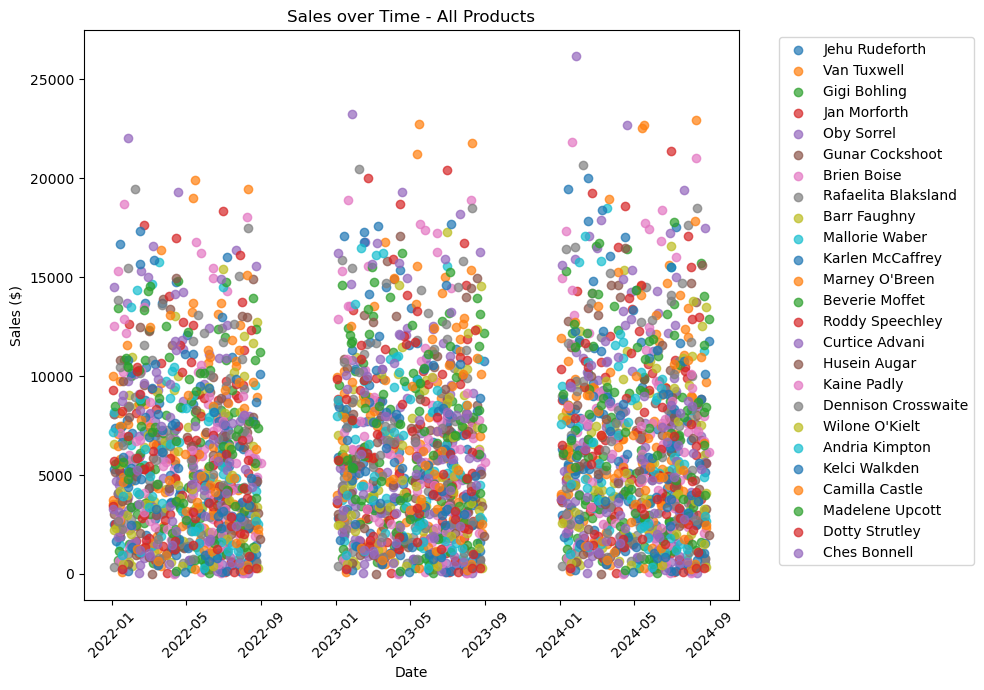

In [22]:
# | echo: false
plt.figure(figsize=(10, 7))

for person in df["Sales Person"].unique():
    person_data = df[df["Sales Person"] == person]

    plt.scatter(
        person_data["Date"],
        person_data["Amount"],
        label=person,
        alpha=0.7
    )

plt.title("Sales over Time - All Products")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Data are sparse with the unusual seasonal pattern.


## Random Forest Regressor Model

In [23]:
#  trend feature 
df["year_trend"] = df["Year"] - df["Year"].min()

kf = KFold(n_splits=5, shuffle=False)

amount_mae_list = []
boxes_mae_list = []

amount_pct_list = []
boxes_pct_list = []

# features
for train_idx, test_idx in kf.split(df):

    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    # --- feature engineering ---
    global_avg = train_df["Amount"].mean()

    product_avg = train_df.groupby("Product")["Amount"].mean()
    person_avg = train_df.groupby("Sales Person")["Amount"].mean()
    country_avg = train_df.groupby("Country")["Amount"].mean()
    year_avg = train_df.groupby("Year")["Amount"].mean()
    quarter_avg = train_df.groupby("Quarter")["Amount"].mean()

    product_country_avg = train_df.groupby(["Product", "Country"])["Amount"].mean()
    product_person_avg = train_df.groupby(["Product", "Sales Person"])["Amount"].mean()
    product_year_avg = train_df.groupby(["Product", "Year"])["Amount"].mean()
    product_month_avg = train_df.groupby(["Product", "Month"])["Amount"].mean()

    person_country_avg = train_df.groupby(["Sales Person", "Country"])["Amount"].mean()

    def add_features(data):
        out = data.copy()

        out["product_avg"] = out["Product"].map(product_avg).fillna(global_avg)
        out["person_avg"] = out["Sales Person"].map(person_avg).fillna(global_avg)
        out["country_avg"] = out["Country"].map(country_avg).fillna(global_avg)
        out["year_avg"] = out["Year"].map(year_avg).fillna(global_avg)
        out["quarter_avg"] = out["Quarter"].map(quarter_avg).fillna(global_avg)

        out["product_country_avg"] = out.apply(
            lambda row: product_country_avg.get((row["Product"], row["Country"]), global_avg),
            axis=1
        )

        out["product_person_avg"] = out.apply(
            lambda row: product_person_avg.get((row["Product"], row["Sales Person"]), global_avg),
            axis=1
        )

        out["product_year_avg"] = out.apply(
            lambda row: product_year_avg.get((row["Product"], row["Year"]), global_avg),
            axis=1
        )

        out["product_month_avg"] = out.apply(
            lambda row: product_month_avg.get((row["Product"], row["Month"]), global_avg),
            axis=1
        )

        out["person_country_avg"] = out.apply(
            lambda row: person_country_avg.get((row["Sales Person"], row["Country"]), global_avg),
            axis=1
        )

        
        out["year_trend"] = out["Year"] - df["Year"].min()

        return out

    train_feat = add_features(train_df)
    test_feat = add_features(test_df)

    feature_cols = [
        "quarter_avg",
        "product_avg",
        "person_avg",
        "country_avg",
        "product_country_avg",
        "product_person_avg",
        "product_month_avg",
        "person_country_avg",
        "year_trend"
    ]

    X_train = train_feat[feature_cols]
    X_test = test_feat[feature_cols]

    y_train = train_feat[["Amount", "Boxes Shipped"]]
    y_test = test_feat[["Amount", "Boxes Shipped"]]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # --- fold MAE ---
    amount_mae = mean_absolute_error(y_test["Amount"], preds[:, 0])
    boxes_mae = mean_absolute_error(y_test["Boxes Shipped"], preds[:, 1])

    # --- fold MAE % ---
    amount_pct = amount_mae / y_test["Amount"].mean()
    boxes_pct = boxes_mae / y_test["Boxes Shipped"].mean()

    amount_mae_list.append(amount_mae)
    boxes_mae_list.append(boxes_mae)

    amount_pct_list.append(amount_pct)
    boxes_pct_list.append(boxes_pct)

# --- fold-average results ---
print("FOLD-AVERAGED RESULTS")
print(f"Amount MAE: {np.mean(amount_mae_list):.2f}")
print(f"Amount MAE %: {np.mean(amount_pct_list):.2%}")

print(f"Boxes Shipped MAE: {np.mean(boxes_mae_list):.2f}")
print(f"Boxes Shipped MAE %: {np.mean(boxes_pct_list):.2%}")


FOLD-AVERAGED RESULTS
Amount MAE: 552.16
Amount MAE %: 9.12%
Boxes Shipped MAE: 25.50
Boxes Shipped MAE %: 15.49%


#### Final Evaluation

In [24]:
# --- separate actual values ---
y_test_amount = y_test["Amount"].values
y_test_boxes = y_test["Boxes Shipped"].values

# --- separate predictions ---
pred_amount = preds[:, 0]
pred_boxes = preds[:, 1]

# --- MAE ---
mae_amount = mean_absolute_error(y_test_amount, pred_amount)
mae_boxes = mean_absolute_error(y_test_boxes, pred_boxes)

# --- MAE % ---
mae_amount_pct = mae_amount / y_test_amount.mean()
mae_boxes_pct = mae_boxes / y_test_boxes.mean()

# --- print ---
print(f"Amount MAE: {mae_amount:.2f}")
print(f"Amount MAE %: {mae_amount_pct:.2%}")

print(f"Boxes Shipped MAE: {mae_boxes:.2f}")
print(f"Boxes Shipped MAE %: {mae_boxes_pct:.2%}")

Amount MAE: 664.61
Amount MAE %: 10.37%
Boxes Shipped MAE: 25.53
Boxes Shipped MAE %: 14.85%


## Prediciton for the Year 2025

In [25]:
# training of model on all history

train_full = add_features(df)

X_full = train_full[feature_cols]
y_full = train_full[["Amount", "Boxes Shipped"]]

final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_full, y_full)


# building future 2025 dataset
# copy last real year structure


future_2025 = filtered_2024.copy()
future_2025["Year"] = 2025
future_2025["Date"] = pd.to_datetime(future_2025["Date"]) + pd.DateOffset(years=1)
future_2025["Month"] = future_2025["Date"].dt.month
future_2025["Quarter"] = future_2025["Date"].dt.quarter

future_2025 = future_2025.drop(columns=["Amount", "Boxes Shipped"], errors="ignore")

# predict 2025
future_2025_feat = add_features(future_2025)
future_preds = final_model.predict(future_2025_feat[feature_cols])

future_2025["Predicted Amount"] = future_preds[:, 0]
future_2025["Predicted Boxes Shipped"] = future_preds[:, 1]
# conservative growth rate around 4.8%
growth_rate = 0.048
future_2025["Predicted Amount"] = future_2025["Predicted Amount"] * (1+growth_rate)
future_2025["Predicted Boxes Shipped"] = future_2025["Predicted Boxes Shipped"] * (1+ growth_rate)
future_2025=future_2025.reset_index()
future_2025.head()

,index,Sales Person,Country,Product,Date,Year,Month,Month Label,Quarter,Predicted Amount,Predicted Boxes Shipped
0,2188,Jehu Rudeforth,UK,Mint Chip Choco,2025-01-04,2025,1,2024-01,1,6496.683000,215.11772
1,2189,Van Tuxwell,India,85% Dark Bars,2025-08-01,2025,8,2024-08,3,9143.718570,101.75032
2,2190,Gigi Bohling,India,Peanut Butter Cubes,2025-07-07,2025,7,2024-07,3,5305.962168,105.04104
3,2191,Jan Morforth,Australia,Peanut Butter Cubes,2025-04-27,2025,4,2024-04,2,14254.663973,325.49308
4,2192,Jehu Rudeforth,UK,Peanut Butter Cubes,2025-02-24,2025,2,2024-02,1,14624.041791,197.45892


In [26]:
# | echo: false

print(f"\nSales Persons: {future_2025['Sales Person'].unique()}\n")
print(f"\nCountries: {future_2025['Country'].unique()}\n")
print(f"\nProducts: {future_2025['Product'].unique()}\n")
print(f"\nRange: {future_2025['Date'].min()} - {df['Date'].max()}")
total_amount = future_2025['Predicted Amount'].sum()
print(f"\nPredicted Amount: {total_amount.round(2)}")
total_boxes = future_2025['Predicted Boxes Shipped'].sum()
print(f"\nPredicted Boxes Shipped: {total_boxes.round()}\n")
print(future_2025.info())


Sales Persons: ['Jehu Rudeforth' 'Van Tuxwell' 'Gigi Bohling' 'Jan Morforth' 'Oby Sorrel'
 'Gunar Cockshoot' 'Brien Boise' 'Rafaelita Blaksland' 'Barr Faughny'
 'Mallorie Waber' 'Karlen McCaffrey' "Marney O'Breen" 'Beverie Moffet'
 'Roddy Speechley' 'Curtice Advani' 'Husein Augar' 'Kaine Padly'
 'Dennison Crosswaite' "Wilone O'Kielt" 'Andria Kimpton' 'Kelci Walkden'
 'Camilla Castle' 'Madelene Upcott' 'Dotty Strutley' 'Ches Bonnell']


Countries: ['UK' 'India' 'Australia' 'New Zealand' 'USA' 'Canada']


Products: ['Mint Chip Choco' '85% Dark Bars' 'Peanut Butter Cubes'
 'Smooth Silky Salty' '99% Dark & Pure' 'After Nines' '50% Dark Bites'
 'Orange Choco' 'Eclairs' 'Drinking Choco' 'Organic Choco Syrup'
 'Milk Bars' 'Spicy Special Slims' 'Fruit & Nut Bars' 'White Choc'
 'Manuka Honey Choco' 'Almond Choco' 'Raspberry Choco'
 'Choco Coated Almonds' "Baker's Choco Chips" 'Caramel Stuffed Bars'
 '70% Dark Bites']


Range: 2025-01-03 00:00:00 - 2024-08-31 00:00:00

Predicted Amount: 7166263

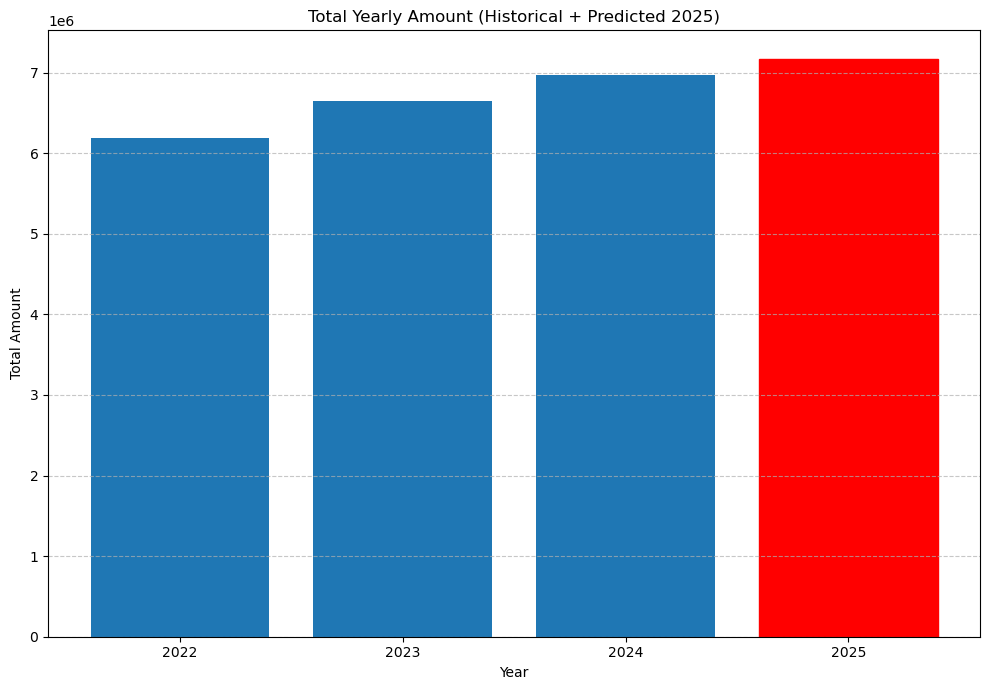

In [27]:
# | echo: false

hist_yearly = df.groupby("Year")["Amount"].sum().reset_index()

# predicted total for 2025
pred_2025_total = future_2025["Predicted Amount"].sum()

# add 2025 row
future_row = pd.DataFrame({
    "Year": [2025],
    "Amount": [pred_2025_total]
})

# combine
plot_df = pd.concat([hist_yearly, future_row], ignore_index=True)

plt.figure(figsize=(10, 7))

bars = plt.bar(plot_df["Year"].astype(str), plot_df["Amount"])

# highlight 2025 in different color
bars[-1].set_color("red")

plt.title("Total Yearly Amount (Historical + Predicted 2025)")
plt.xlabel("Year")
plt.ylabel("Total Amount")

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
# | echo: false

future_2025.to_csv("future_2025_predictions.csv", index=False)

---
### End